In [5]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

file_path = 'advertising.csv'
df = pd.read_csv(file_path)

num1, num2 = df.shape
num3 = df.isnull().sum()
print(df.columns)
print(f"co {num1} mau, co {num2} dac trung")
print(f"{num3}")



Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')
co 200 mau, co 4 dac trung
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


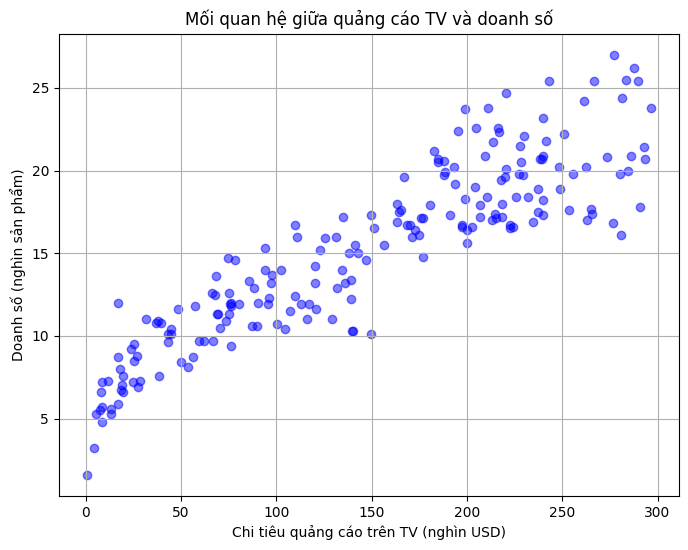

In [6]:

plt.figure(figsize=(8, 6))  # Thiết lập kích thước biểu đồ
plt.scatter(df['TV'], df['Sales'], color='blue', alpha=0.5)  # Vẽ điểm dữ liệu
plt.xlabel('Chi tiêu quảng cáo trên TV (nghìn USD)')  # Nhãn trục X
plt.ylabel('Doanh số (nghìn sản phẩm)')  # Nhãn trục Y
plt.title('Mối quan hệ giữa quảng cáo TV và doanh số')  # Tiêu đề biểu đồ
plt.grid(True)  # Hiển thị lưới
plt.show()  # Hiển thị biểu đồ


In [7]:
df[['TV', 'Sales']].corr()

,TV,Sales
TV,1.000000,0.901208
Sales,0.901208,1.000000


In [8]:
X = df['TV'].values
y = df['Sales'].values
def my_train_test_split(X, y, test_size = 0.2, random_state = None):
    X = np.array(X)
    y = np.array(y)
    if random_state is not None:
        np.random.seed(random_state)
    
    n_samples = X.shape[0]
    
    test_size = int(n_samples * test_size)
    
    indices = np.random.permutation(n_samples)
    
    test_indices = indices[:test_size]
    train_indices = indices[test_size:]
    
    X_train = X[train_indices]
    X_test = X[test_indices]
    y_train = y[train_indices]
    y_test = y[test_indices]
    return X_train, X_test, y_train, y_test
X_scaled = (X - X.min())/(X.max()- X.min())
print(X_scaled)

X_train, X_test, y_train, y_test = my_train_test_split(X_scaled, y, 0.2, 42)

print (X_train, X_test)
print (y_train, y_test)

[0.77578627 0.1481231  0.0557998  0.50997633 0.60906324 0.02705445
 0.19208657 0.4041258  0.02671627 0.67331755 0.2211701  0.72370646
 0.07811972 0.32735881 0.68785932 0.65843761 0.22691917 0.94927291
 0.2316537  0.49577274 0.73621914 0.80047345 0.04227257 0.76969902
 0.20831924 0.8867095  0.4808928  0.80960433 0.83902604 0.23638823
 0.98816368 0.37943862 0.32634427 0.89584038 0.32127156 0.98072371
 0.90023673 0.25025364 0.14338857 0.76868448 0.68244843 0.59621238
 0.99053094 0.69732837 0.08251606 0.58978695 0.30098072 0.80892797
 0.76597903 0.22387555 0.67331755 0.33716605 0.72945553 0.61515049
 0.88603314 0.67027393 0.02231992 0.4582347  0.71051742 0.71017924
 0.17855935 0.88129861 0.80689888 0.3449442  0.44098749 0.23097734
 0.10415962 0.4687183  0.80047345 0.73080825 0.67095029 0.36895502
 0.08826513 0.43523842 0.71931011 0.05478526 0.0906324  0.40514034
 0.01589449 0.38992222 0.25600271 0.80858979 0.25228272 0.22894826
 0.71964829 0.65099763 0.25566452 0.37199865 0.2962462  0.3689

In [9]:
def predict(X, w0, w1):
    return np.array(w0 + w1 * X)

def loss_function(y_true, y_pred):
    return np.mean(((y_true - y_pred) ** 2))

def gradient(X, y, w0, w1):
    n = int(X.shape[0])
    y_pred = predict(X, w0, w1)
    dw0 = (-2.0/n) * (np.sum(y - y_pred))
    dw1 = (-2.0/n) * (np.sum(X * (y - y_pred)))
    return dw0, dw1

In [10]:
lr = 0.01
epochs = 30000
w0 = 0
w1 = 0
losses = []

for epoch in range(epochs):
    dw0, dw1 = gradient(X_train, y_train, w0, w1)
    w0 -= lr * dw0
    w1 -= lr * dw1
    y_pred = predict(X_train, w0, w1)
    loss = loss_function(y_train, y_pred)
    losses.append(loss)
    if epoch % 100 == 0:
        print(f'Epoch {epoch}, Loss {loss}')

Epoch 0, Loss 249.2967385959615
Epoch 100, Loss 12.421795490634569
Epoch 200, Loss 9.702502128802633
Epoch 300, Loss 8.638388957918087
Epoch 400, Loss 7.819641359413933
Epoch 500, Loss 7.185084776043444
Epoch 600, Loss 6.693255626838331
Epoch 700, Loss 6.31205083568854
Epoch 800, Loss 6.016588288444483
Epoch 900, Loss 5.7875824657144195
Epoch 1000, Loss 5.61008563123081
Epoch 1100, Loss 5.472512158748253
Epoch 1200, Loss 5.365882311596483
Epoch 1300, Loss 5.283236114633974
Epoch 1400, Loss 5.219179060677554
Epoch 1500, Loss 5.169529998622865
Epoch 1600, Loss 5.131048220104182
Epoch 1700, Loss 5.101221931012761
Epoch 1800, Loss 5.078104300923676
Epoch 1900, Loss 5.060186389000482
Epoch 2000, Loss 5.0462986519595265
Epoch 2100, Loss 5.0355346052923995
Epoch 2200, Loss 5.027191654939119
Epoch 2300, Loss 5.020725237359395
Epoch 2400, Loss 5.015713274619027
Epoch 2500, Loss 5.011828624393283
Epoch 2600, Loss 5.008817726635639
Epoch 2700, Loss 5.006484053130902
Epoch 2800, Loss 5.00467527964

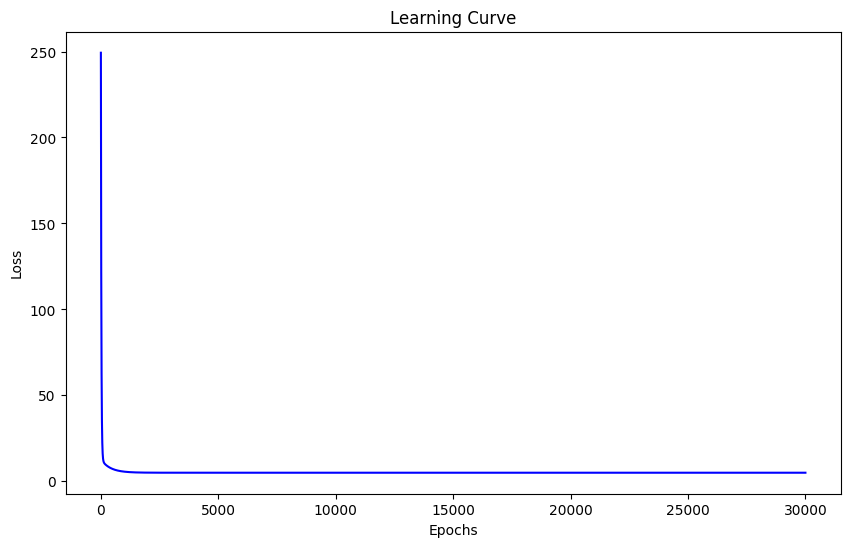

In [11]:
plt.figure(figsize=(10, 6))
plt.plot(losses, color='blue')
plt.title('Learning Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

In [12]:
def evaluate(X, y, w0, w1):
    n = len(y)
    y_pred = predict(X, w0, w1)

    mse = np.mean((y - y_pred) ** 2)
    
    rmse = np.sqrt(np.sum((y - y_pred) ** 2) / n)
    
    mae = np.mean(np.abs(y - y_pred))

    y_mean = np.mean(y)
    tss = np.sum((y - y_mean) ** 2)

    rss = np.sum((y - y_pred) ** 2)

    r2 = 1 - (rss / tss)
    return mse, rmse, mae, r2

Mean Squared Error: 6.10107290677397
Root Mean Squared Error: 2.4700350011232572
Mean Absolute Error: 1.9502948931650022
R-squared: 0.8025613034236978


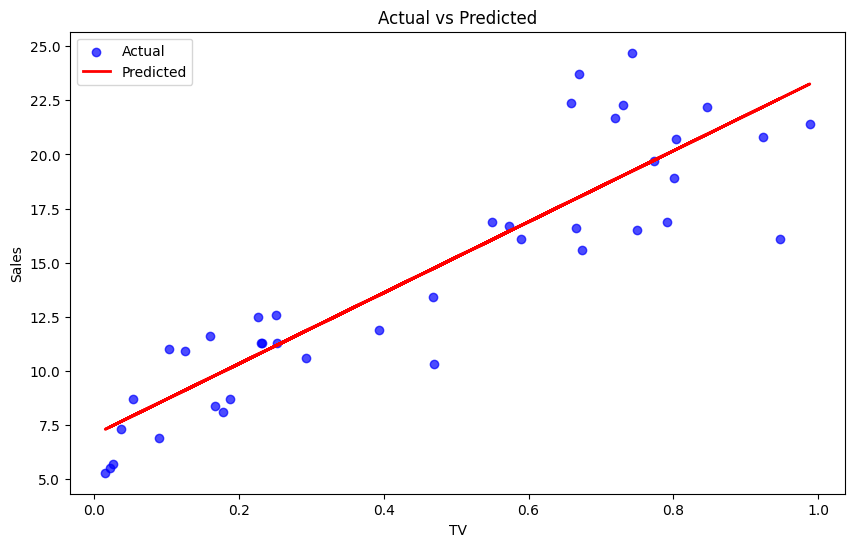

In [13]:
y_pred = predict(X_test, w0, w1)
mse, rmse, mae, r2 = evaluate(X_test, y_test, w0, w1)
print(f'Mean Squared Error: {mse}')
print(f'Root Mean Squared Error: {rmse}')
print(f'Mean Absolute Error: {mae}')
print(f'R-squared: {r2}')
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='blue', label='Actual', alpha=0.7)
plt.plot(X_test, y_pred, color='red', label='Predicted', linewidth = 2)
plt.title('Actual vs Predicted')
plt.xlabel('TV')
plt.ylabel('Sales')
plt.legend()
plt.show()